In [91]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:
import torch
import numpy as np
import xarray as xr
from pathlib import Path
import os
import random

from torch import nn

from sklearn.metrics import mean_squared_error
from hython.preprocess import reshape, apply_normalization
from hython.datasets.datasets import LSTMDataset
from hython.train_val import train_val
from hython.sampler import RegularIntervalSampler, DataLoaderSpatialSampler
from hython.metrics import mse_metric
from hython.losses import RMSELoss

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset

from hython.utils import missing_location_idx, reconstruct_from_missing, load
from hython.models.lstm import CustomLSTM

# viz
import matplotlib.pyplot as plt
from hython.viz import plot_sampler
from hython.utils import predict, prepare_for_plotting
from hython.viz import map_bias, map_pbias, map_pearson, map_at_timesteps, ts_compare, plot_sampler

def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(43)

# Settings

In [93]:
dynamic_names = ["precip", "pet", "temp"]
static_names = [ 'thetaS', 'thetaR', 'RootingDepth', 'Swood','KsatVer'] #, 'TT', 'KsatHorFrac'] 
target_names = [ "vwc","actevap" ] # "q_river"]

fn_forcings =  "forcings.nc"  # 'inmaps_eobs_eobsd_makkink_86400_2015_2019.nc' 
fn_params = "staticmaps.nc"
fn_targets = "output.nc"


timeslice = slice("2016-01-01","2020-12-31")

In [95]:
# DEMO 

# wflow_model = "datademo" #"adg1km_eobs" #"datademo" # "alps1km_eobs" # "alps1km_cerra", 

# wd = Path("../data") / wflow_model

# fp_dynamic_forcings = wd / fn_forcings 
# fp_wflow_static_params = wd / fn_params
# fp_target = wd / fn_targets

# forcings = xr.open_dataset(fp_dynamic_forcings)
# params = xr.open_dataset(fp_wflow_static_params)
# targets = xr.open_dataset(fp_target).isel(lat=slice(None, None, -1))

In [96]:
# EURAC FILE SYSTEM

wflow_model =  "adg1km_eobs" # "alps1km_eobs" #

wd = Path("/mnt/CEPH_PROJECTS/InterTwin/Wflow/models") / wflow_model

input_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/Wflow/models') / wflow_model
output_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/surrogate/')
model_weigths_path = output_dir_path / "model_weights"
surrogate_input_path = Path("/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/surrogate_training")

forcings = xr.open_dataset(input_dir_path / fn_forcings , chunks= {"time":100})
params = xr.open_dataset(input_dir_path / fn_params ,  chunks= {"time":100}).sel(layer=1)
targets = xr.open_dataset(input_dir_path / "run_default" / fn_targets, chunks= {"time":100}).sel(layer=1).isel(lat=slice(None, None, -1))

In [97]:
#(surrogate_input_path / f"{wflow_model}.npz").exists()

In [98]:
# select forcings, wflow parameters and targets
forcings = forcings[dynamic_names]
params = params[static_names]
targets = targets[target_names] 

In [99]:
## Show distribution of static parameters
# for i in static_names:
#     plt.figure(figsize=(2,2))
#     params[i].plot.hist(bins=100)

In [100]:
## Show map of static parameters
# for i in static_names:
#     plt.figure(figsize=(2,2))
#     params[i].plot()

In [101]:
try:
    forcings = forcings.rename({"latitude":"lat", "longitude":"lon"})
    params = params.rename({"latitude":"lat", "longitude":"lon"})
except:
    pass

# Hyper parameters

In [102]:
# training 

spatial_batch_size = 128
temporal_sampling_size = 150 
seq_length = 260 # days

# model 

hidden_size = 32

model_params={
    "input_size": 3, #number of dynamic predictors - user_input
    "hidden_size": hidden_size, # user_input
    "output_size": len(target_names), # number_target - user_input
    "number_static_predictors": len(static_names), #number of static parameters - user_input 

}

## The used device for training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Preprocess

In [103]:
remove_lakes = True

if remove_lakes:
    mask_lakes = (targets.mean(dim = "time")["actevap"] == 0).astype(np.bool_)
    targets = targets.where(~mask_lakes, np.nan)
    forcings = forcings.where(~mask_lakes, np.nan)
    params = params.where(~mask_lakes, np.nan)


if timeslice:
    forcings = forcings.sel(time=timeslice)
    targets = targets.sel(time=timeslice)

In [104]:
# UNCOMMENT IF NOT LOADING PREPROCESSED INPUTS

#reshape for training

Xd, Xs, Y  = reshape(
                   forcings, 
                   params, 
                   targets
                   )

#Define the 2D missing values mask. Sampling 

missing_mask = np.isnan(params[static_names[0]]).values

# UNCOMMENT TO SAVE
# np.savez_compressed( surrogate_input_path / f"{wflow_model}", Xd=Xd, Xs=Xs, Y=Y, missing_mask = missing_mask)

dynamic:  (40140, 1827, 3)  => (GRIDCELL, TIME, FEATURE)
static:  (40140, 5)  => (GRIDCELL, FEATURE)
target:  (40140, 1827, 2)  => (GRIDCELL, TIME, TARGET)


In [105]:
# UNCOMMENT IF LOADING PREPROCESSED INPUTS
# Xd, Xs, Y, missing_mask = load(surrogate_input_path, wflow_model, files = ["Xd", "Xs", "Y", "missing_mask"])
# Xd.shape, Xs.shape, Y.shape, missing_mask.shape

In [106]:
# Define the spatial samplers for both training and validation sets. Remeber the subsets should not overlap, so choose different origins.

intervals = (5, 5) # every n km
train_origin = (0, 0)
val_origin = (3, 3)

spatial_train_sampler = RegularIntervalSampler(intervals = intervals, origin = train_origin)
spatial_val_sampler = RegularIntervalSampler(intervals = intervals, origin = val_origin) 

In [107]:
# Apply the samplers: return the cell indices that can be used later in training and validation to sample the whole spatial domain.

data2d  = forcings.to_dataarray().transpose("lat","lon", "time", "variable")

sampler_train_meta = spatial_train_sampler.sampling_idx(data2d, missing_mask)
sampler_val_meta = spatial_val_sampler.sampling_idx(data2d, missing_mask)

In [108]:
# some useful metadata
sampler_train_meta

SamplerResult(
 - id_grid_2d: (180, 223) 
 - idx_sampled_1d: (1620,) 
 - idx_sampled_1d_nomissing: (622,)) 
 - idx_missing_1d: (24714,) 
 - sampled_grid_dims: (36, 45, 1827, 3) 
 - xr_coords: Coordinates:
  * time         (time) datetime64[ns] 2016-01-01 2016-01-02 ... 2020-12-31
  * lon          (lon) float64 10.29 10.34 10.38 10.43 ... 12.22 12.26 12.31
  * lat          (lat) float64 47.08 47.04 46.99 46.94 ... 45.57 45.52 45.48
    spatial_ref  int64 ...
    layer        float64 1.0

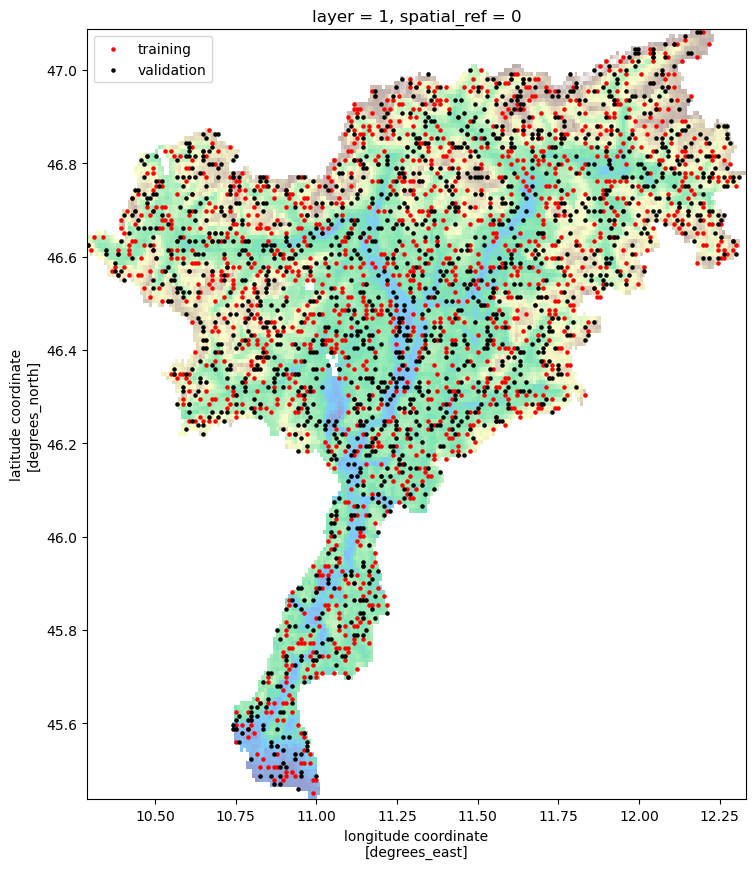

In [219]:
# check location of training and validation sets
_ = plot_sampler(params[static_names[0]], sampler_train_meta, sampler_val_meta, figsize= (10, 10 ), markersize = 5)

In [220]:
# # Normalizing
# # training
_, d_m, d_std = apply_normalization(Xd[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')
_, s_m, s_std = apply_normalization(Xs[sampler_train_meta.idx_sampled_1d_nomissing], type = "space", how ='standard')
_, y_m, y_std = apply_normalization(Y[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')

#print("dynamic mean ",d_m, "dynamic std", d_std, "static mean",s_m, "static std", s_std, "target mean", y_m, "target std", y_std, sep="\n")

In [221]:
Xd = apply_normalization(Xd, type="spacetime", how="standard", m1 = d_m, m2 = d_std)
Xs = apply_normalization(Xs, type="space", how="standard",  m1 = s_m, m2 = s_std)
Y = apply_normalization(Y, type="spacetime",how="standard", m1 = y_m, m2 = y_std)

In [222]:
## Show distribution of static parameters
# for i in range(Xs.shape[1]):
#     plt.figure(figsize= (1, 1))
#     plt.hist(Xs[:,i], bins=100)

In [223]:
## Show distribution of targets
# for i in range(Y.shape[2]):
#     plt.figure(figsize= (1, 1))
#     plt.hist(Xs[:,i], bins=100)

In [224]:
np.isnan(Xd[sampler_val_meta.idx_sampled_1d_nomissing]).any(), np.isnan(Xs[sampler_val_meta.idx_sampled_1d_nomissing]).any(), np.isnan(Y[sampler_val_meta.idx_sampled_1d_nomissing]).any()

(False, False, False)

In [225]:
np.isnan(Xd[sampler_train_meta.idx_sampled_1d_nomissing]).any(), np.isnan(Xs[sampler_train_meta.idx_sampled_1d_nomissing]).any(), np.isnan(Y[sampler_train_meta.idx_sampled_1d_nomissing]).any()

(False, False, False)

# Prepare Model inputs

In [226]:
Xs = torch.Tensor(Xs)
Xd = torch.Tensor(Xd)
Y = torch.Tensor(Y)

Xs.shape, Xd.shape, Y.shape

(torch.Size([40140, 5]),
 torch.Size([40140, 1827, 3]),
 torch.Size([40140, 1827, 2]))

In [227]:
# init datasets
dataset = LSTMDataset(Xd, Y, Xs)

In [228]:
train_sampler = DataLoaderSpatialSampler(dataset, num_samples=100, sampling_indices = sampler_train_meta.idx_sampled_1d_nomissing.tolist())
valid_sampler = DataLoaderSpatialSampler(dataset, num_samples=100, sampling_indices = sampler_val_meta.idx_sampled_1d_nomissing.tolist())

In [229]:
train_loader = DataLoader(dataset, batch_size=spatial_batch_size, shuffle=False, sampler = train_sampler) # implement shuffling in the sampler!
val_loader = DataLoader(dataset, batch_size=spatial_batch_size, shuffle=False, sampler = valid_sampler)

# Initialize Model

In [230]:
model = CustomLSTM(model_params)
model = model.to(device)
model

CustomLSTM(
  (fc0): Linear(in_features=8, out_features=32, bias=True)
  (lstm): LSTM(32, 32, batch_first=True)
  (fc1): Linear(in_features=32, out_features=2, bias=True)
)

# Train/valid settings

In [231]:
path2models= "./checkpoints" 
if not os.path.exists(path2models):
    os.mkdir(path2models)
    
    
opt = optim.Adam(model.parameters(), lr=1e-2)


loss_fn = RMSELoss(target_weight={"actevap":0.5, "vwc":0.5})

metric_fn = mse_metric

lr_scheduler = ReduceLROnPlateau(opt, mode='min',factor=0.5, patience=10)

epochs = 20

params_train={
    "num_epochs": epochs,
    "temporal_sampling_idx_change_with_epoch": True,
    "temporal_sampling_size": temporal_sampling_size,
    "seq_length": seq_length,
    "ts_range": Y.shape[1],
    "optimizer": opt,
    "loss_func": loss_fn,
    "metric_func": metric_fn,
    "train_dl": train_loader, 
    "val_dl": val_loader,
    "lr_scheduler": lr_scheduler,
    "path2weights": f"{path2models}/weights.pt",
    "device":device,
    "target_names": target_names

}

# Run Train/valid

In [232]:
model, sm_loss_history, sm_metric_history = train_val(model, params_train)

Epoch 0/19, current lr=0.01
Copied best model weights!
train loss: 0.624667227268219, train metric: {'vwc': 0.45164177, 'actevap': 0.26932412}
val loss: 0.5636364221572876, val metric: {'vwc': 0.2959598, 'actevap': 0.27627003}
----------
Epoch 1/19, current lr=0.01
Copied best model weights!
train loss: 0.47094470262527466, train metric: {'vwc': 0.24773899, 'actevap': 0.15823396}
val loss: 0.4587288796901703, val metric: {'vwc': 0.21791257, 'actevap': 0.15596026}
----------
Epoch 2/19, current lr=0.01
Copied best model weights!
train loss: 0.43674275279045105, train metric: {'vwc': 0.18539794, 'actevap': 0.15053791}
val loss: 0.4292469620704651, val metric: {'vwc': 0.16077842, 'actevap': 0.1577728}
----------
Epoch 3/19, current lr=0.01
Copied best model weights!
train loss: 0.4385417699813843, train metric: {'vwc': 0.18092607, 'actevap': 0.18030582}
val loss: 0.4252507984638214, val metric: {'vwc': 0.16943045, 'actevap': 0.15873662}
----------
Epoch 4/19, current lr=0.01
train loss: 0

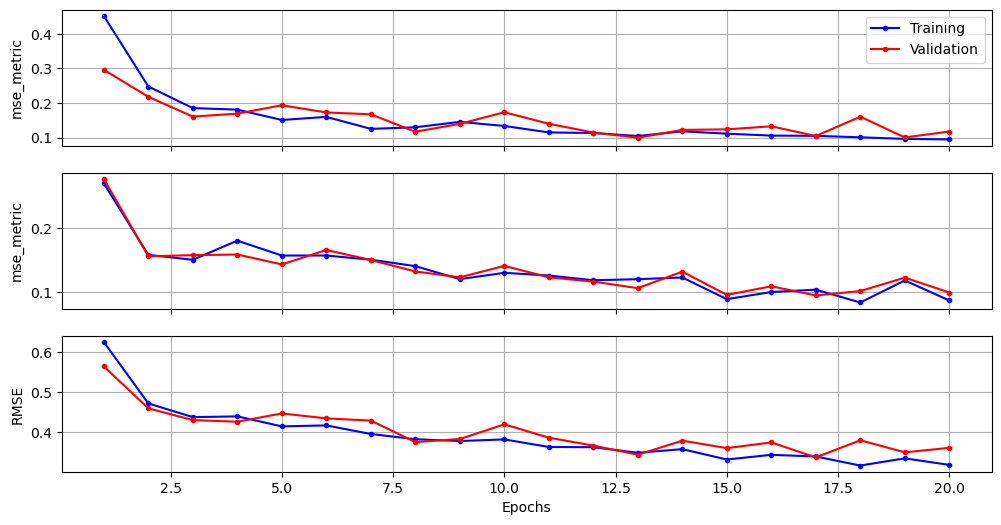

In [235]:
lepochs = list(range(1,params_train["num_epochs"] + 1))

fig, axs = plt.subplots(3, 1, figsize= (12,6), sharex=True)

axs[0].plot(lepochs, sm_metric_history['train_vwc'], marker='.', linestyle='-', color='b', label='Training')
axs[0].plot(lepochs, sm_metric_history['val_vwc'], marker='.', linestyle='-', color='r', label='Validation')
#axs[0].title('Validation Loss - SM')
axs[0].set_ylabel(metric_fn.__name__)
axs[0].grid(True)
axs[0].legend(bbox_to_anchor=(1,1))

axs[1].plot(lepochs, sm_metric_history['train_actevap'], marker='.', linestyle='-', color='b', label='Training')
axs[1].plot(lepochs, sm_metric_history['val_actevap'], marker='.', linestyle='-', color='r', label='Validation')
#axs[0].title('Validation Loss - SM')
axs[1].set_ylabel(metric_fn.__name__)
axs[1].grid(True)

axs[2].plot(lepochs, [i.detach().cpu().numpy() for i in sm_loss_history['train']], marker='.', linestyle='-', color='b', label='Training')
axs[2].plot(lepochs, [i.detach().cpu().numpy() for i in sm_loss_history['val']], marker='.', linestyle='-', color='r', label='Validation')
#axs[0].title('Validation Loss - SM')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel(loss_fn.__name__)
axs[2].grid(True)

In [234]:
#model.load_state_dict(torch.load(params_train["path2weights"]))

# Inference 

In [236]:
torch.cuda.empty_cache()

In [237]:
# predict over the whole spatial domain using the model trained over the subsample
yhat = predict(Xd, Xs, model, spatial_batch_size, device=device)
yhat.shape

(40140, 1827, 2)

In [238]:
lat, lon, time = *forcings.to_dataarray().transpose("lat","lon", "time", "variable").shape[:2], Xd.shape[1]
lat*lon ,time

(40140, 1827)

In [239]:
yhat = (yhat*y_std) + y_m

## SM

In [240]:
# reshape data for plotting
y_target, y_pred = prepare_for_plotting(y_target=Y[:,:,[0]], y_pred = yhat[:,:,[0]], shape = (lat, lon, time), coords = targets.coords)
y_target.shape

(180, 223, 1827)

In [241]:
y_target = (y_target*y_std[0]) + y_m[0]

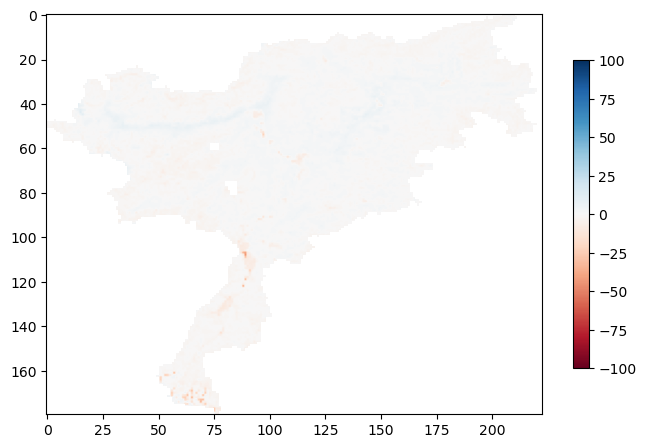

In [242]:
# map percent bias
map_pbias(y_target, y_pred, figsize = (8, 8), kwargs_imshow = {"vmin":-100, "vmax":100 })

/home/iferrario/.local/miniforge/envs/emulator/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/iferrario/.local/miniforge/envs/emulator/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


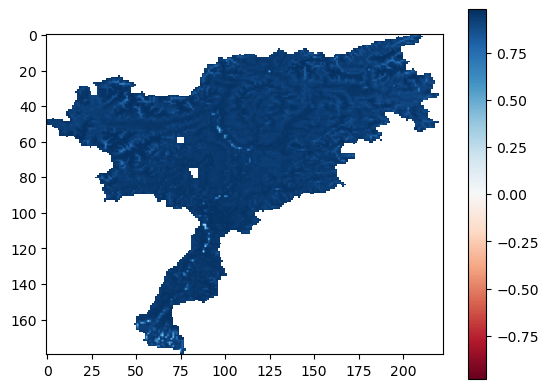

In [243]:
# correlation
map_pearson(y_target, y_pred)

In [244]:
#plt.plot(np.unique(y_pred))

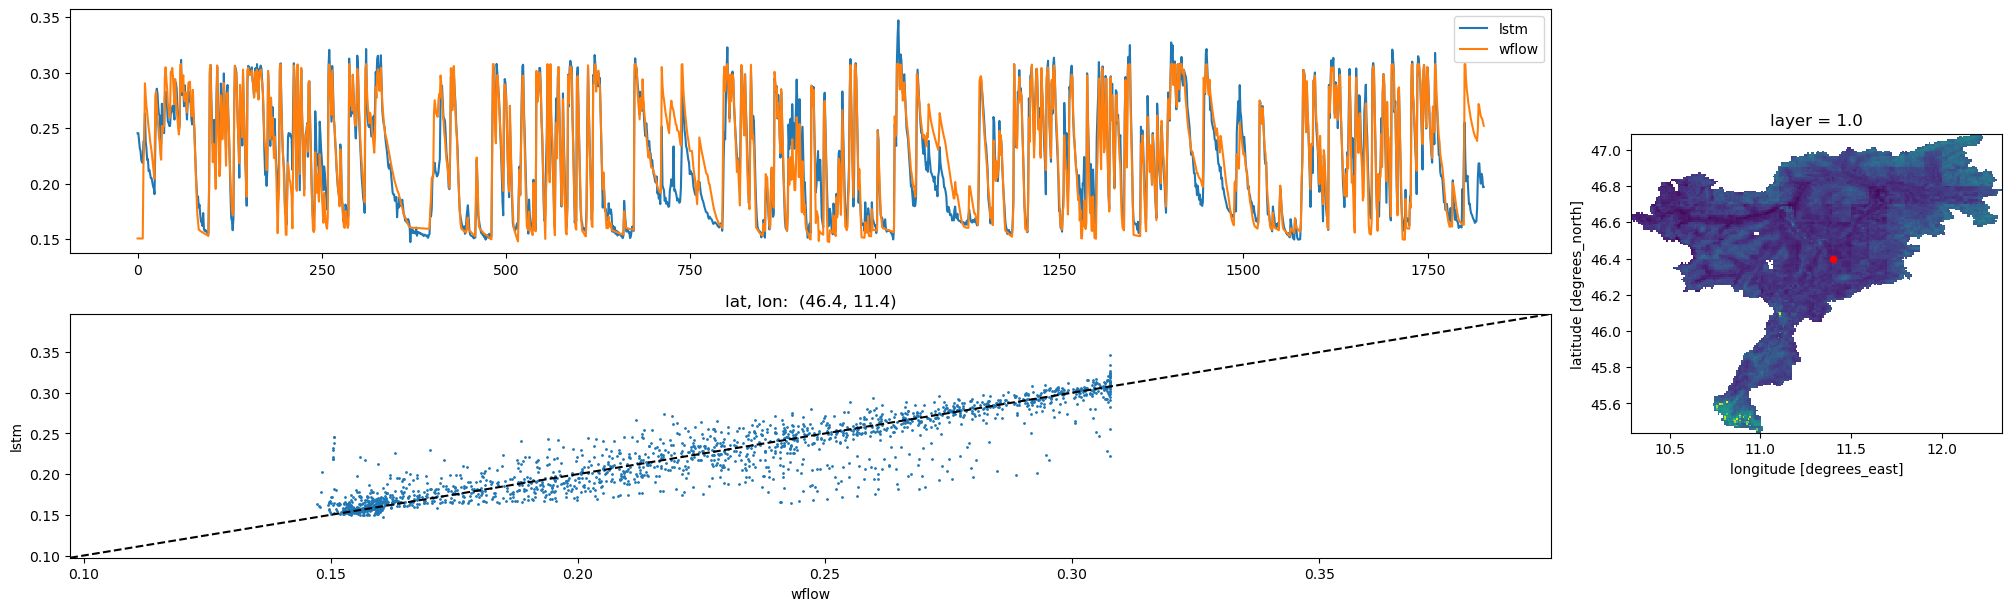

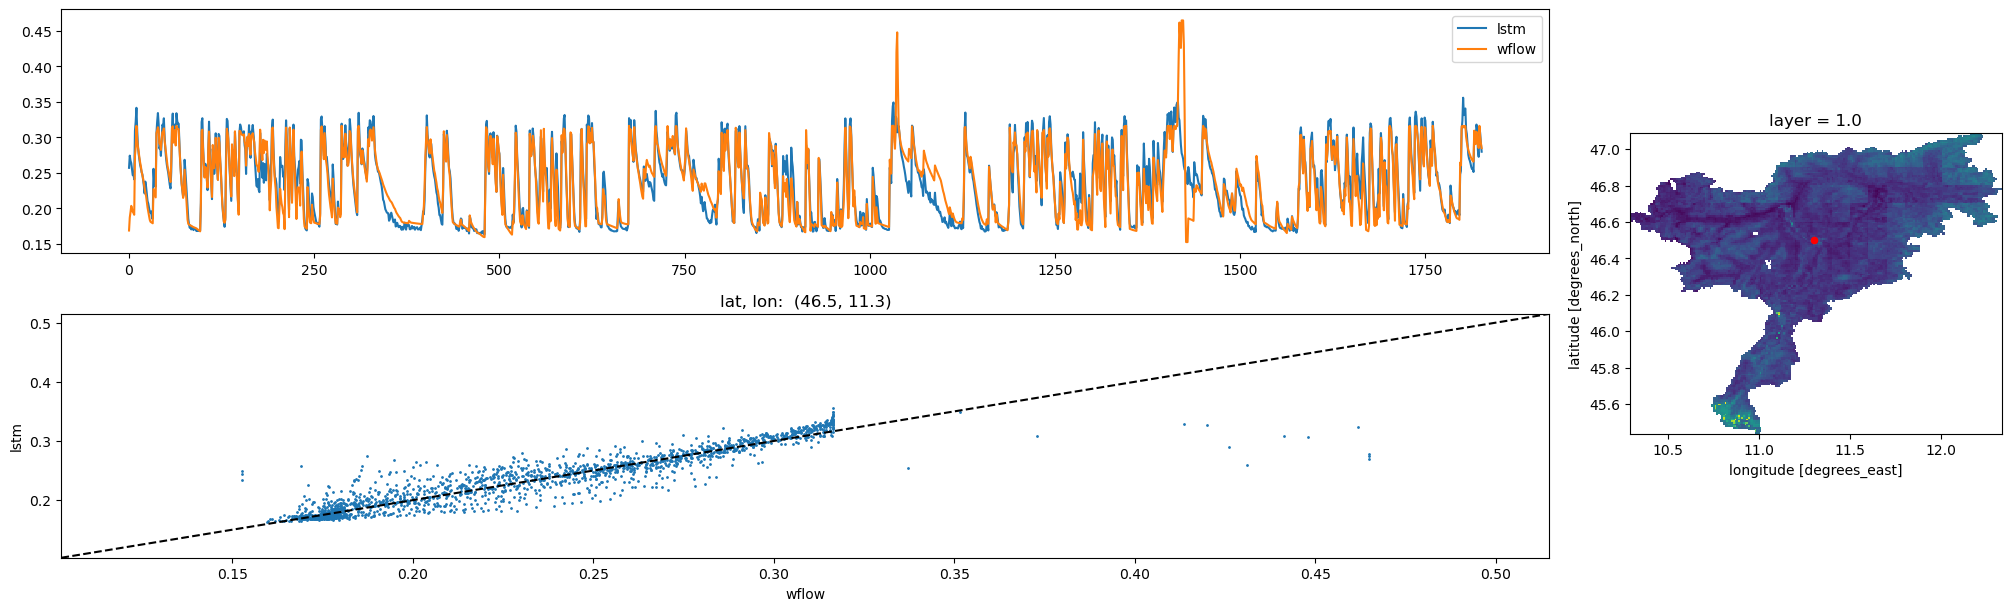

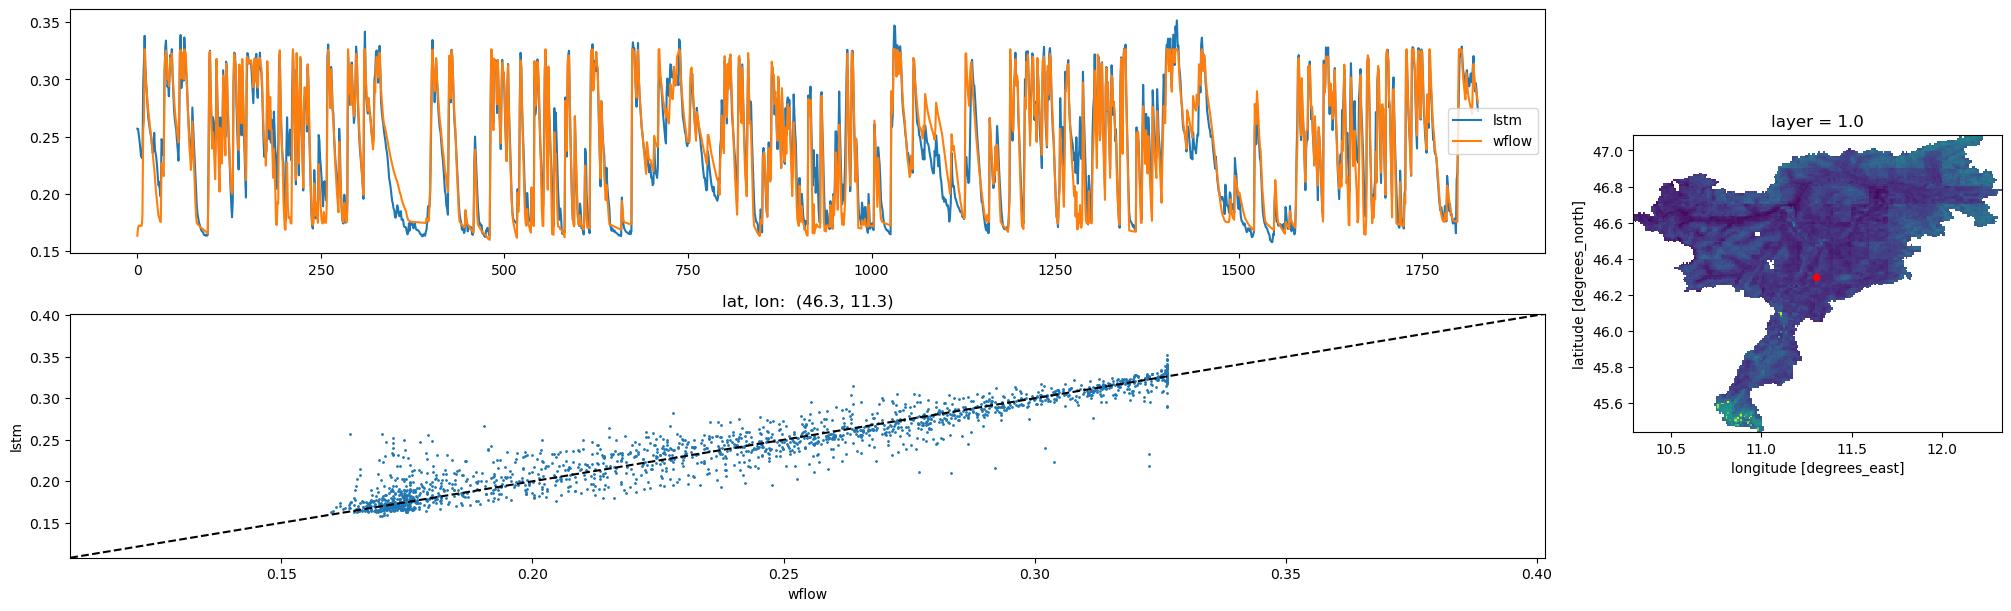

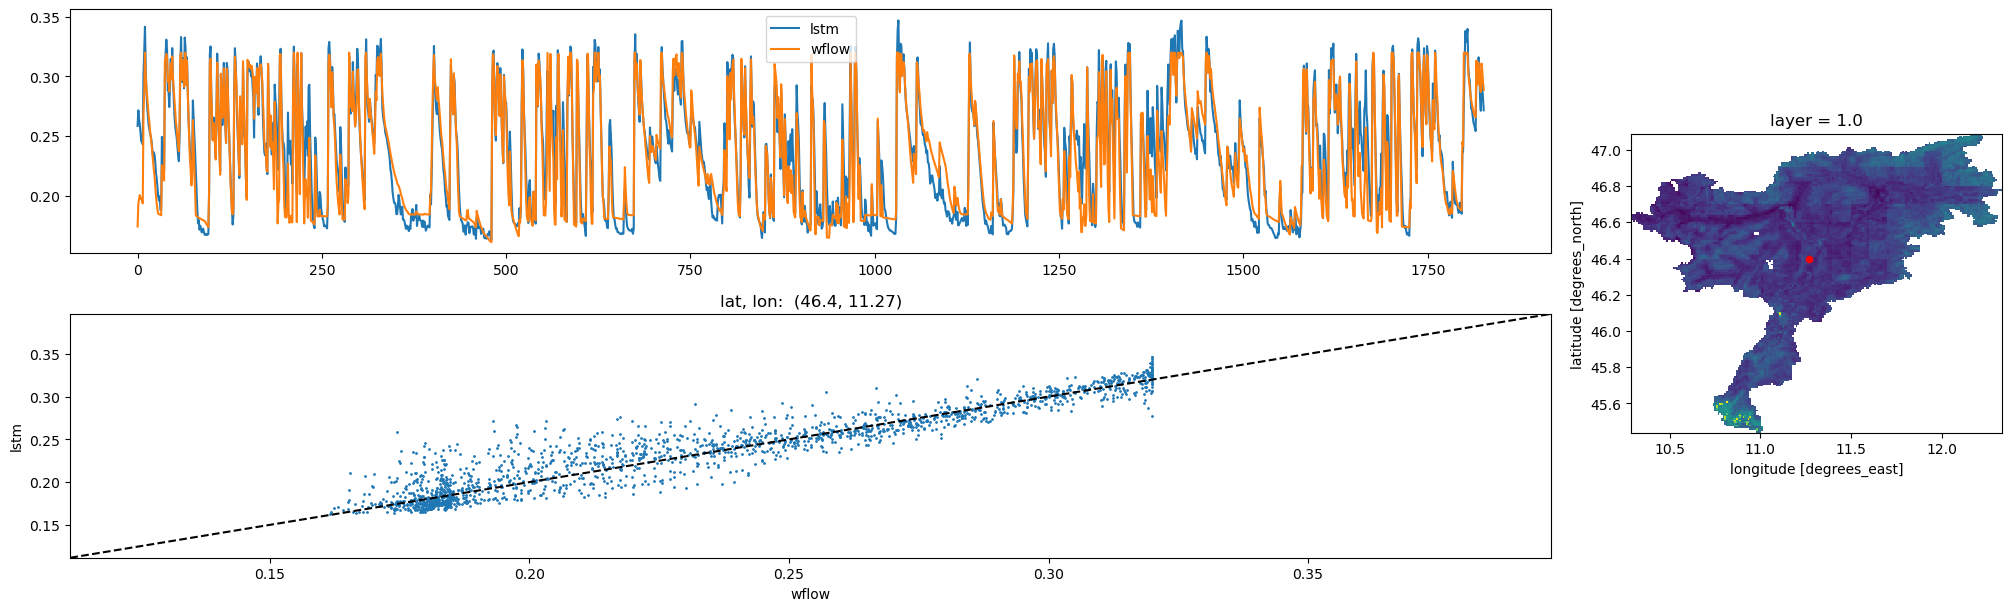

In [245]:
ts_compare(y_target, y_pred, lat = [46.4, 46.5, 46.3, 46.4], lon = [11.4, 11.3, 11.3, 11.27])

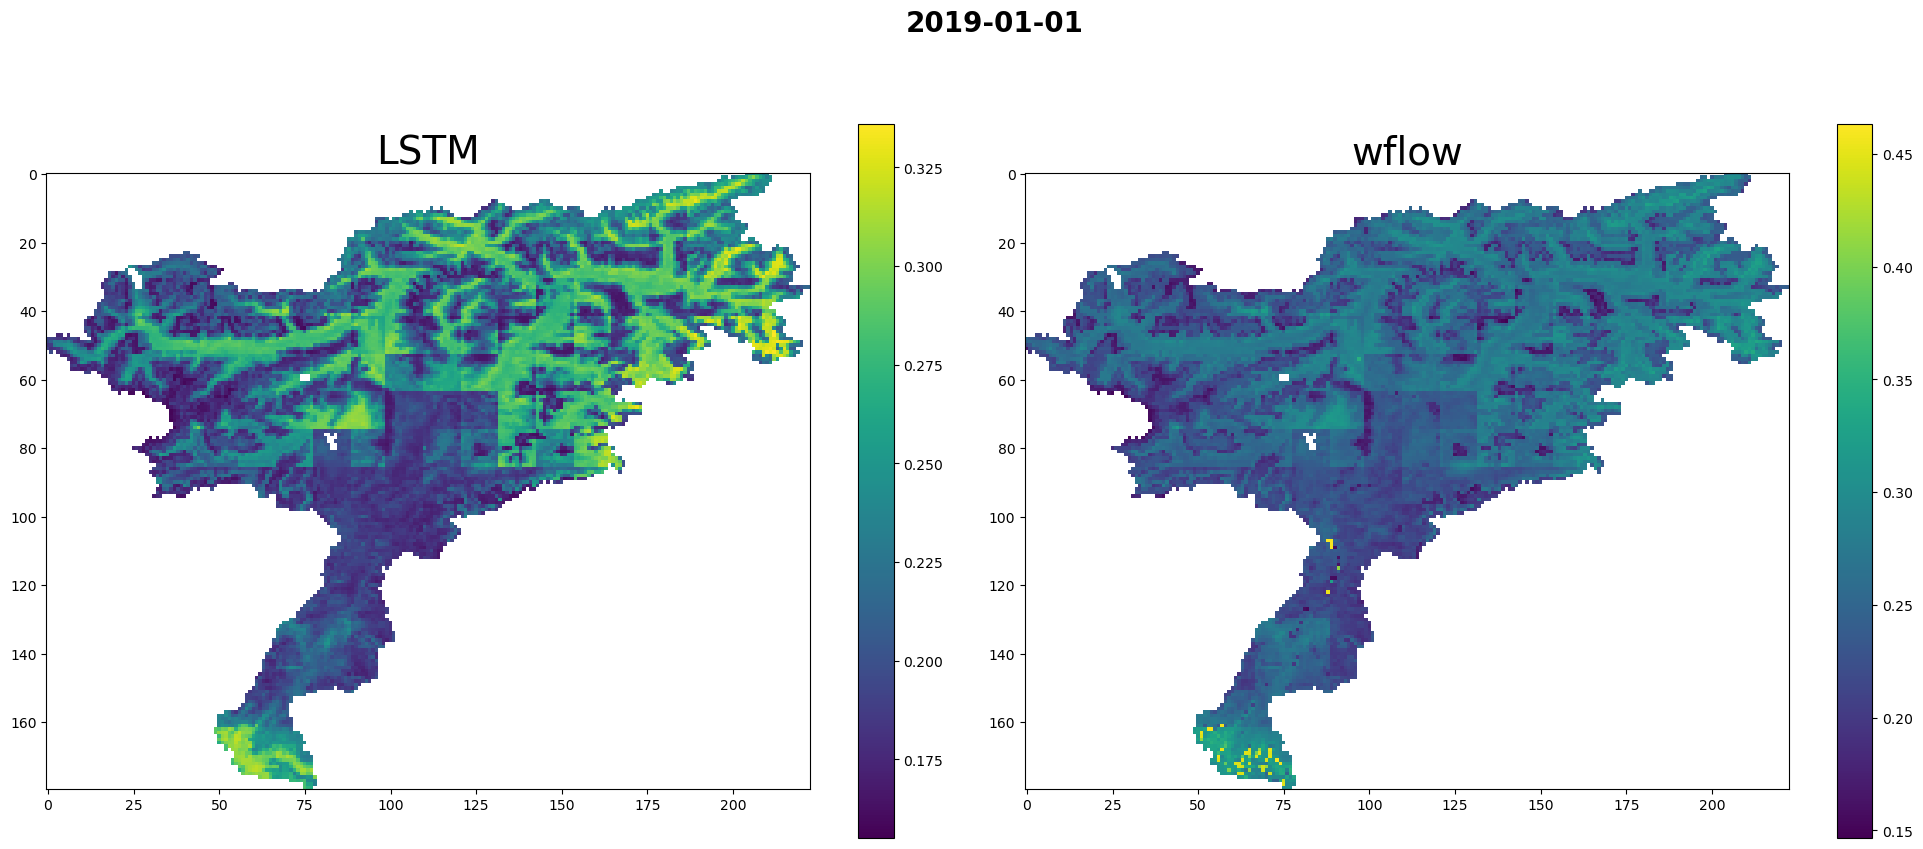

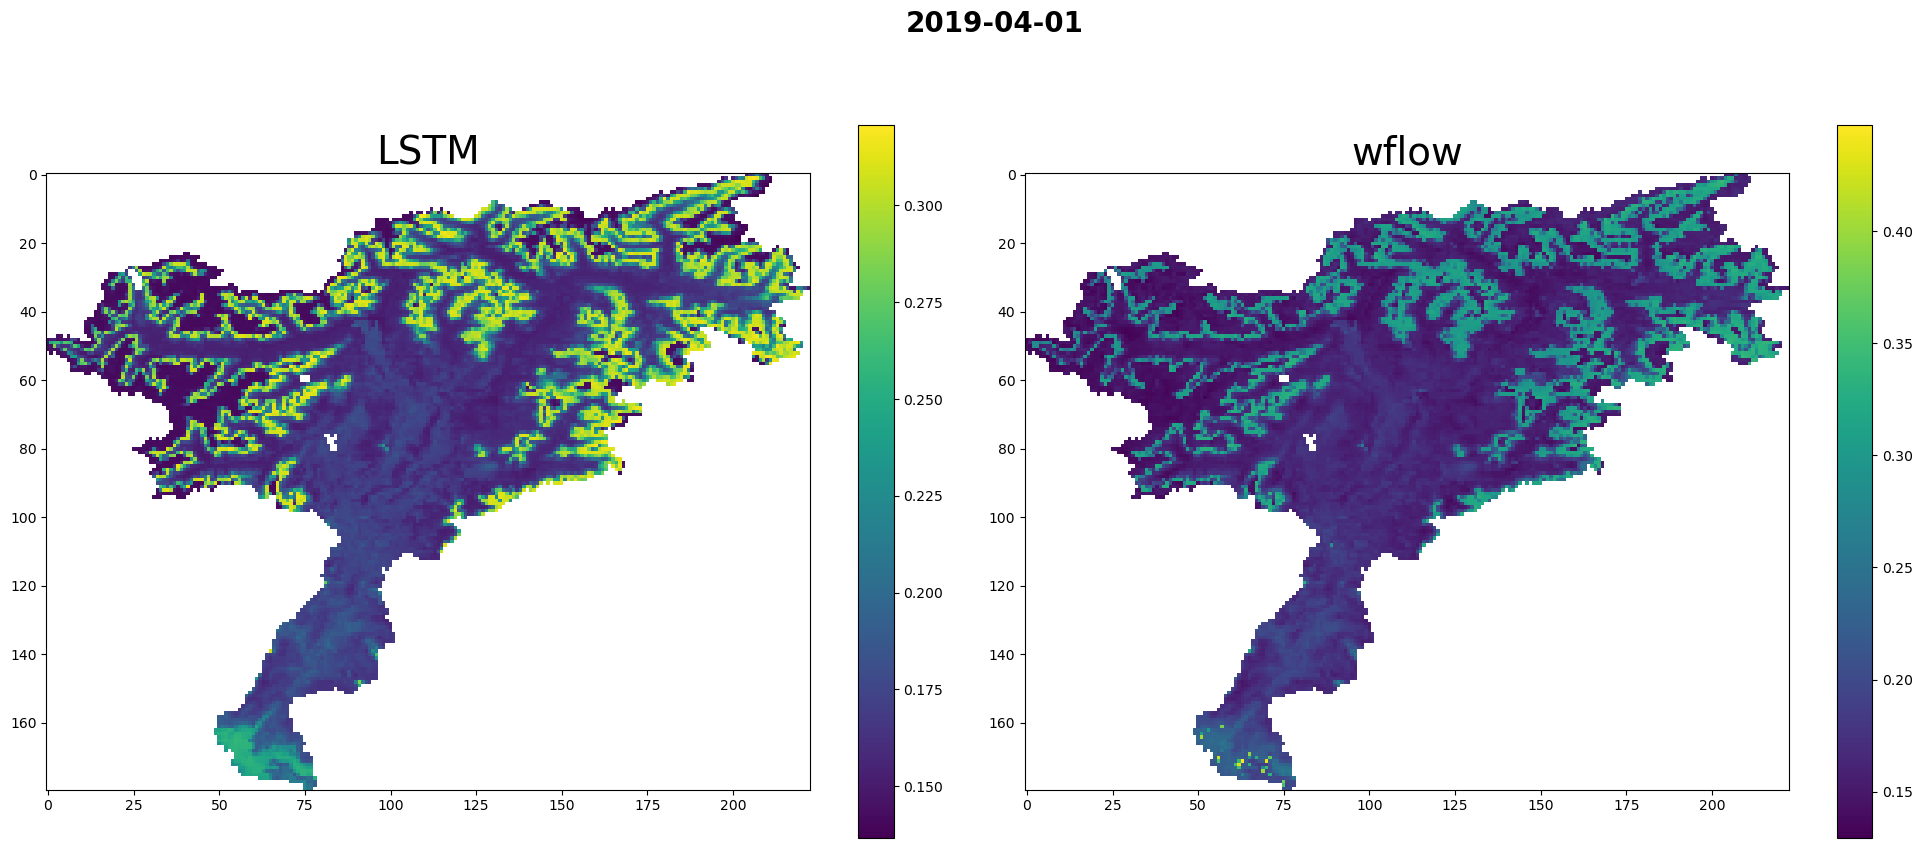

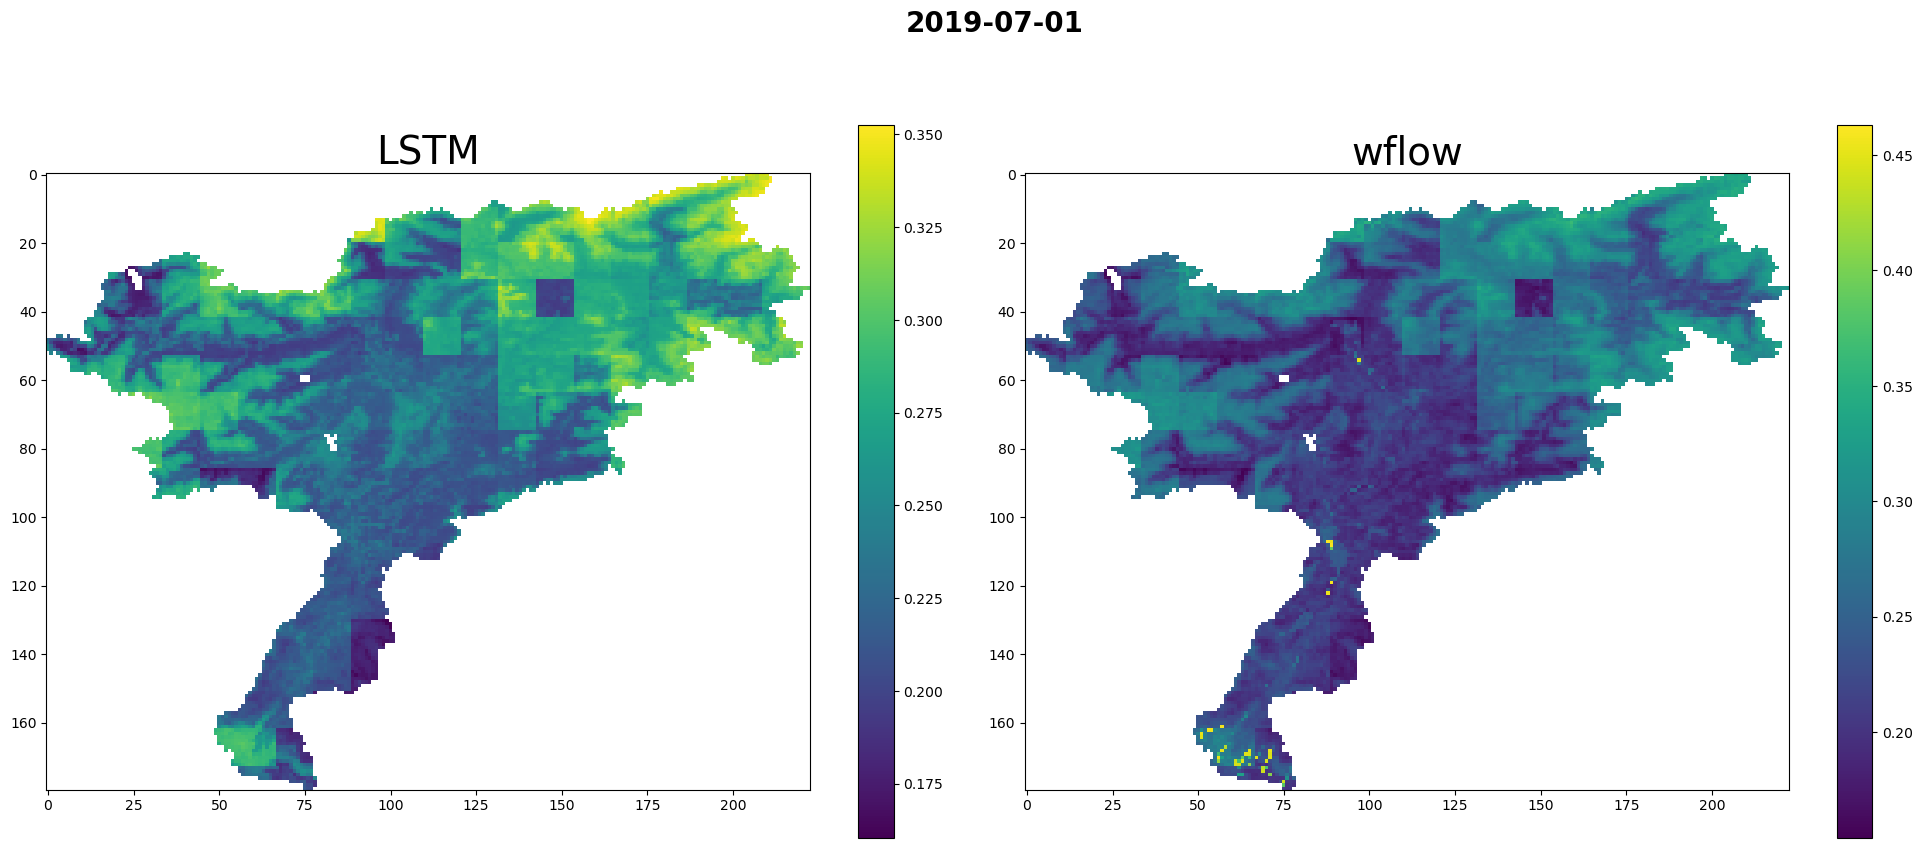

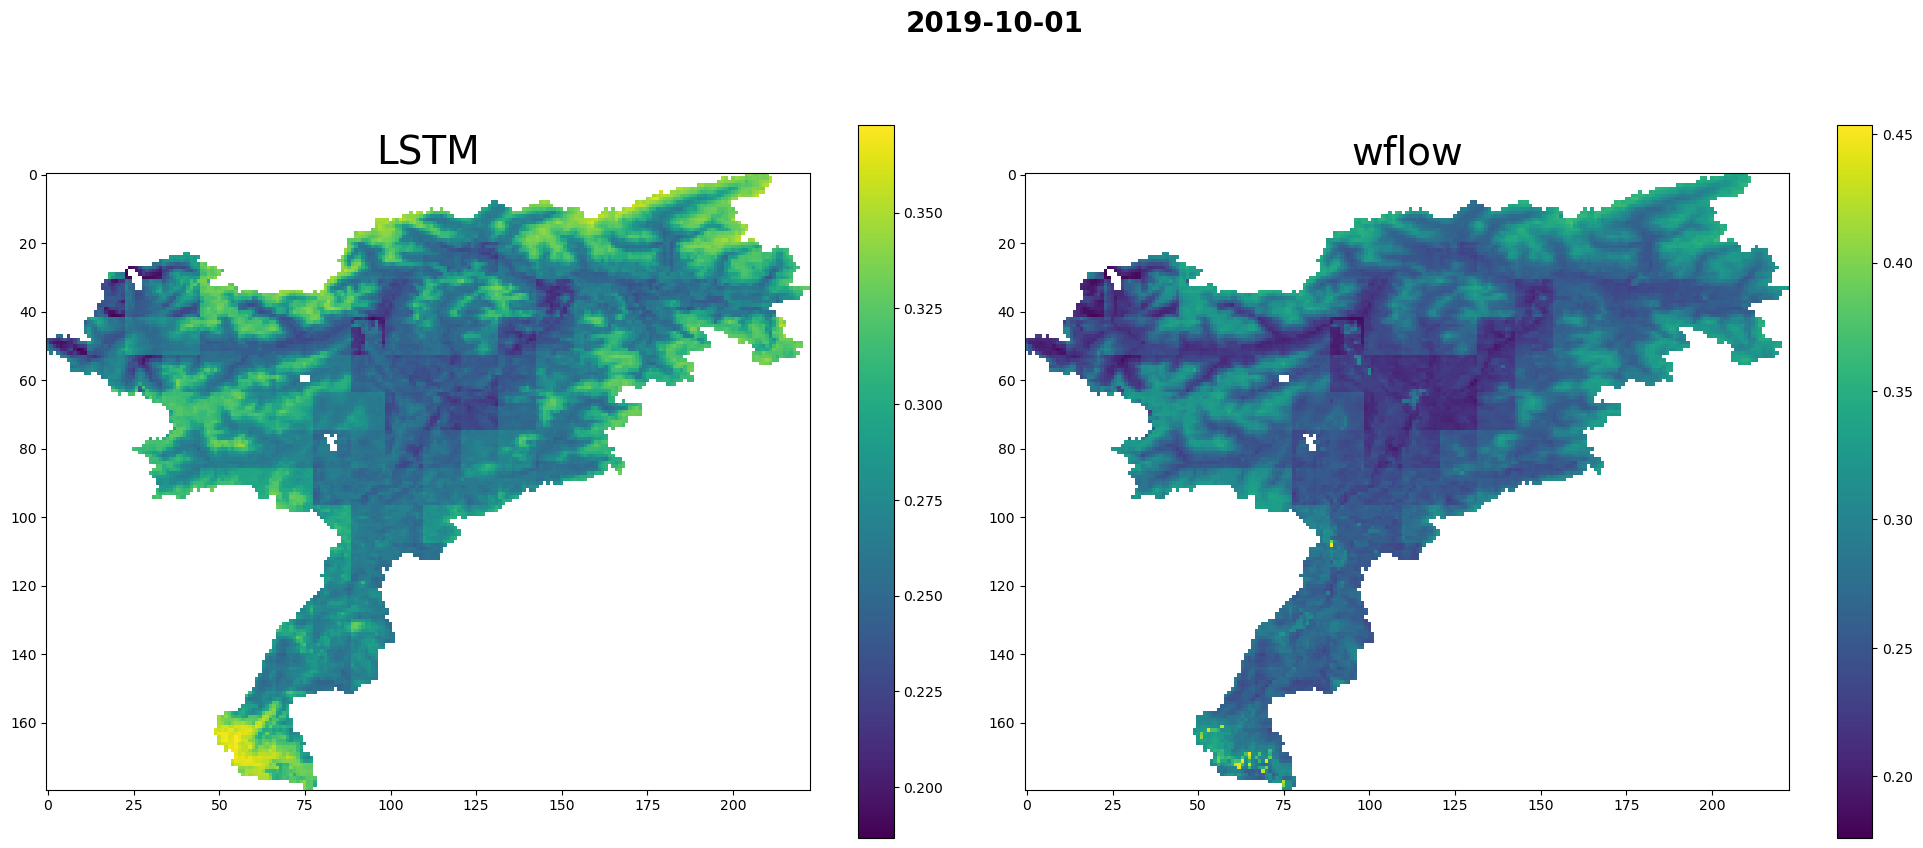

In [246]:
map_at_timesteps(y_target, y_pred,dates=["2019-01-01","2019-04-01", "2019-07-01", "2019-10-01"])

## ET

In [247]:
y_target_et, y_pred_et = prepare_for_plotting(y_target=Y[:,:,[1]], y_pred = yhat[:,:,[1]], shape = (lat, lon, time), coords = targets[target_names].coords)
y_target_et.shape

(180, 223, 1827)

In [248]:
y_target_et = (y_target_et*y_std[1]) + y_m[1]

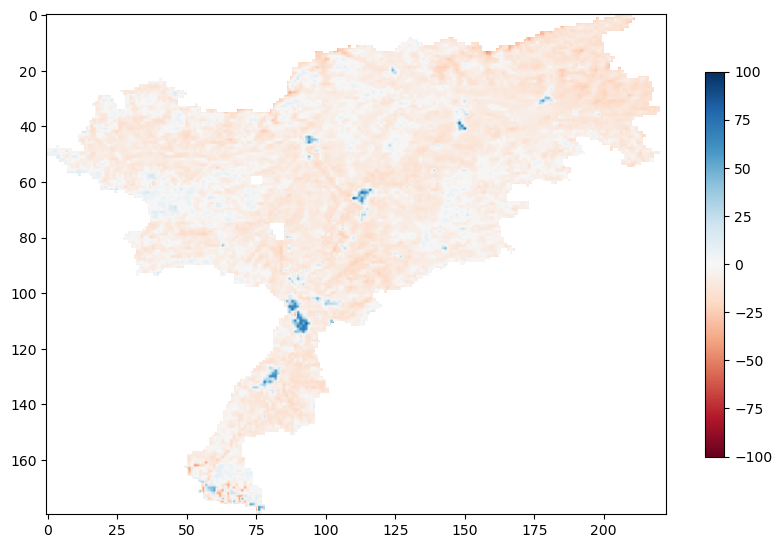

In [249]:
map_pbias(y_target_et, y_pred_et, figsize = (10, 10), kwargs_imshow = {"vmin":-100, "vmax":100 })

/home/iferrario/.local/miniforge/envs/emulator/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/iferrario/.local/miniforge/envs/emulator/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


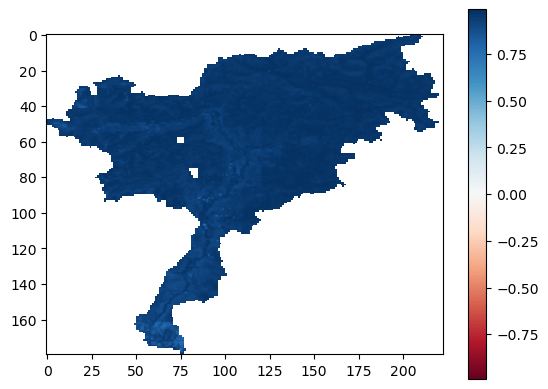

In [250]:
# correlation
map_pearson(y_target_et, y_pred_et)

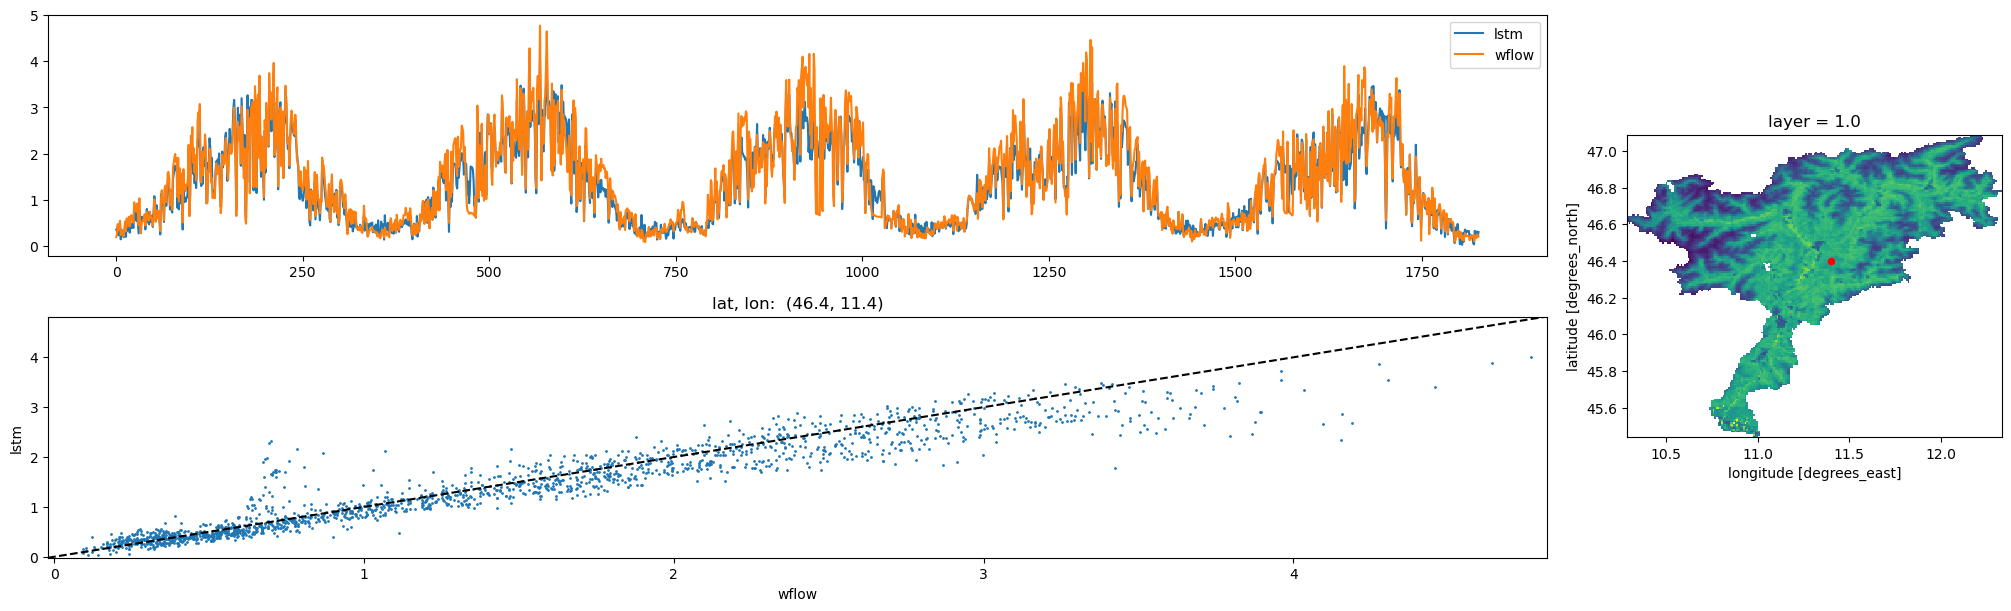

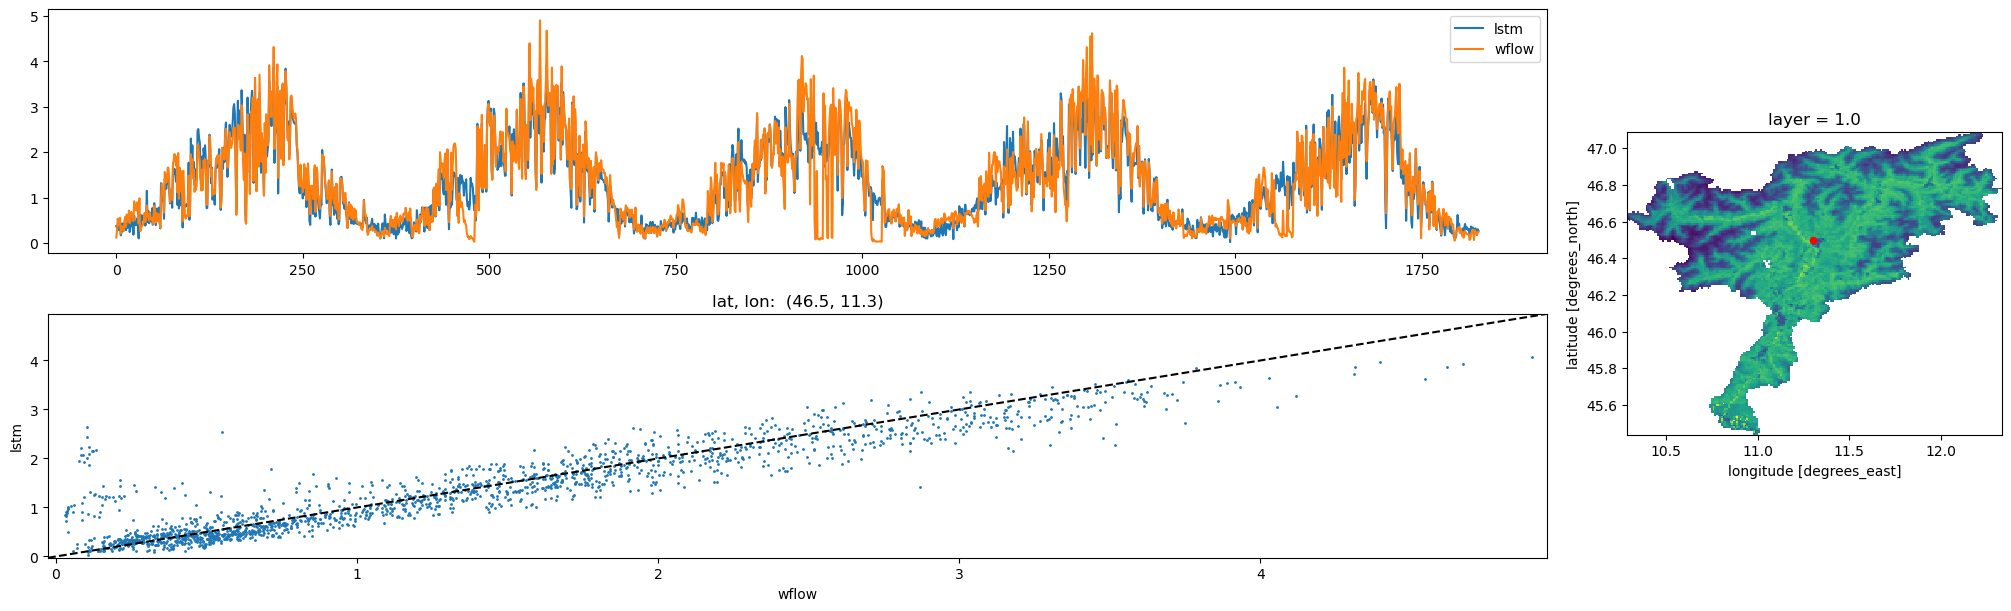

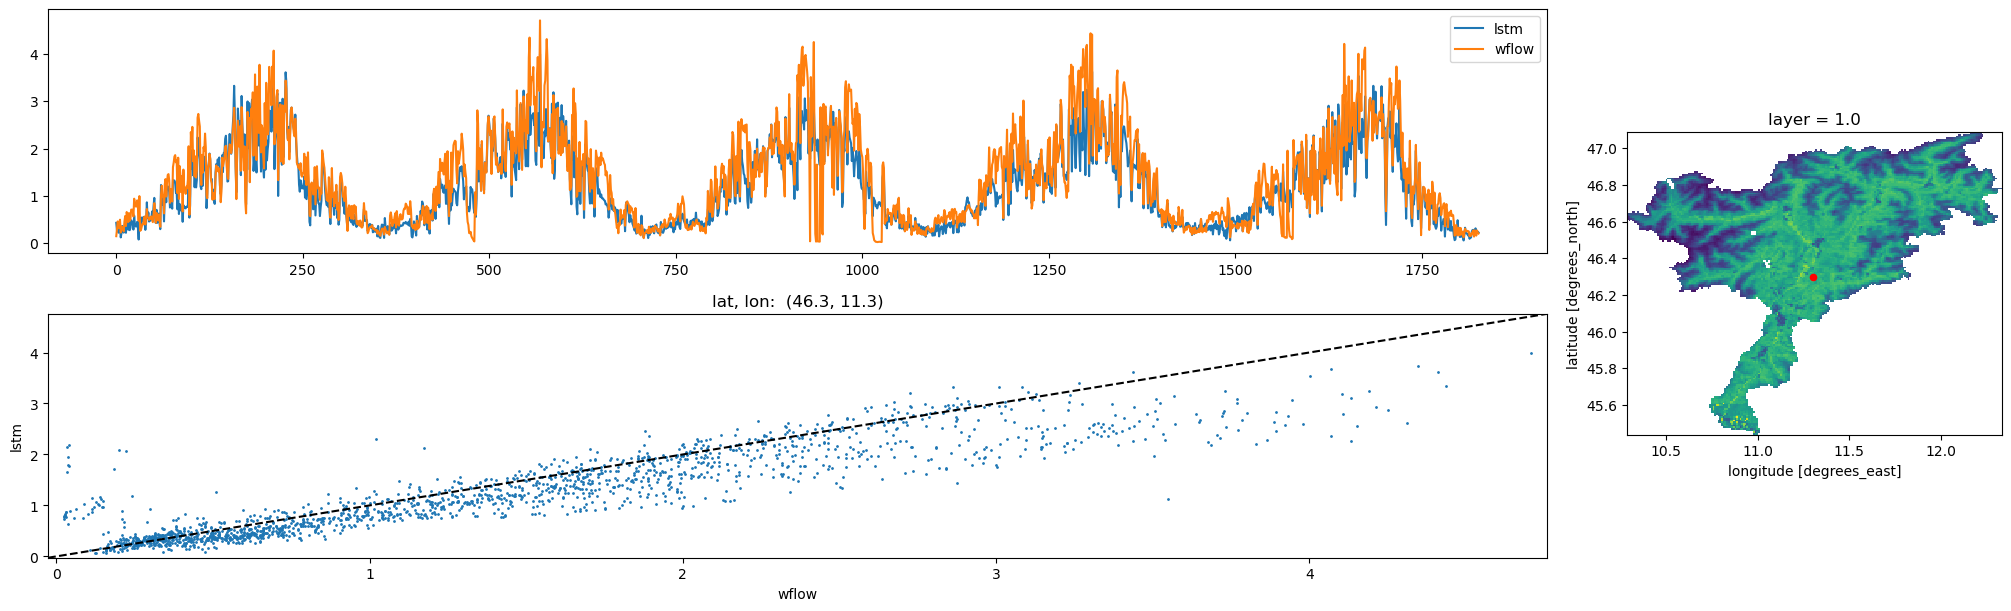

In [251]:
ts_compare(y_target_et, y_pred_et, lat = [46.4, 46.5, 46.3], lon = [11.4, 11.3, 11.3])

In [252]:
#plt.plot(np.unique(y_pred_et))

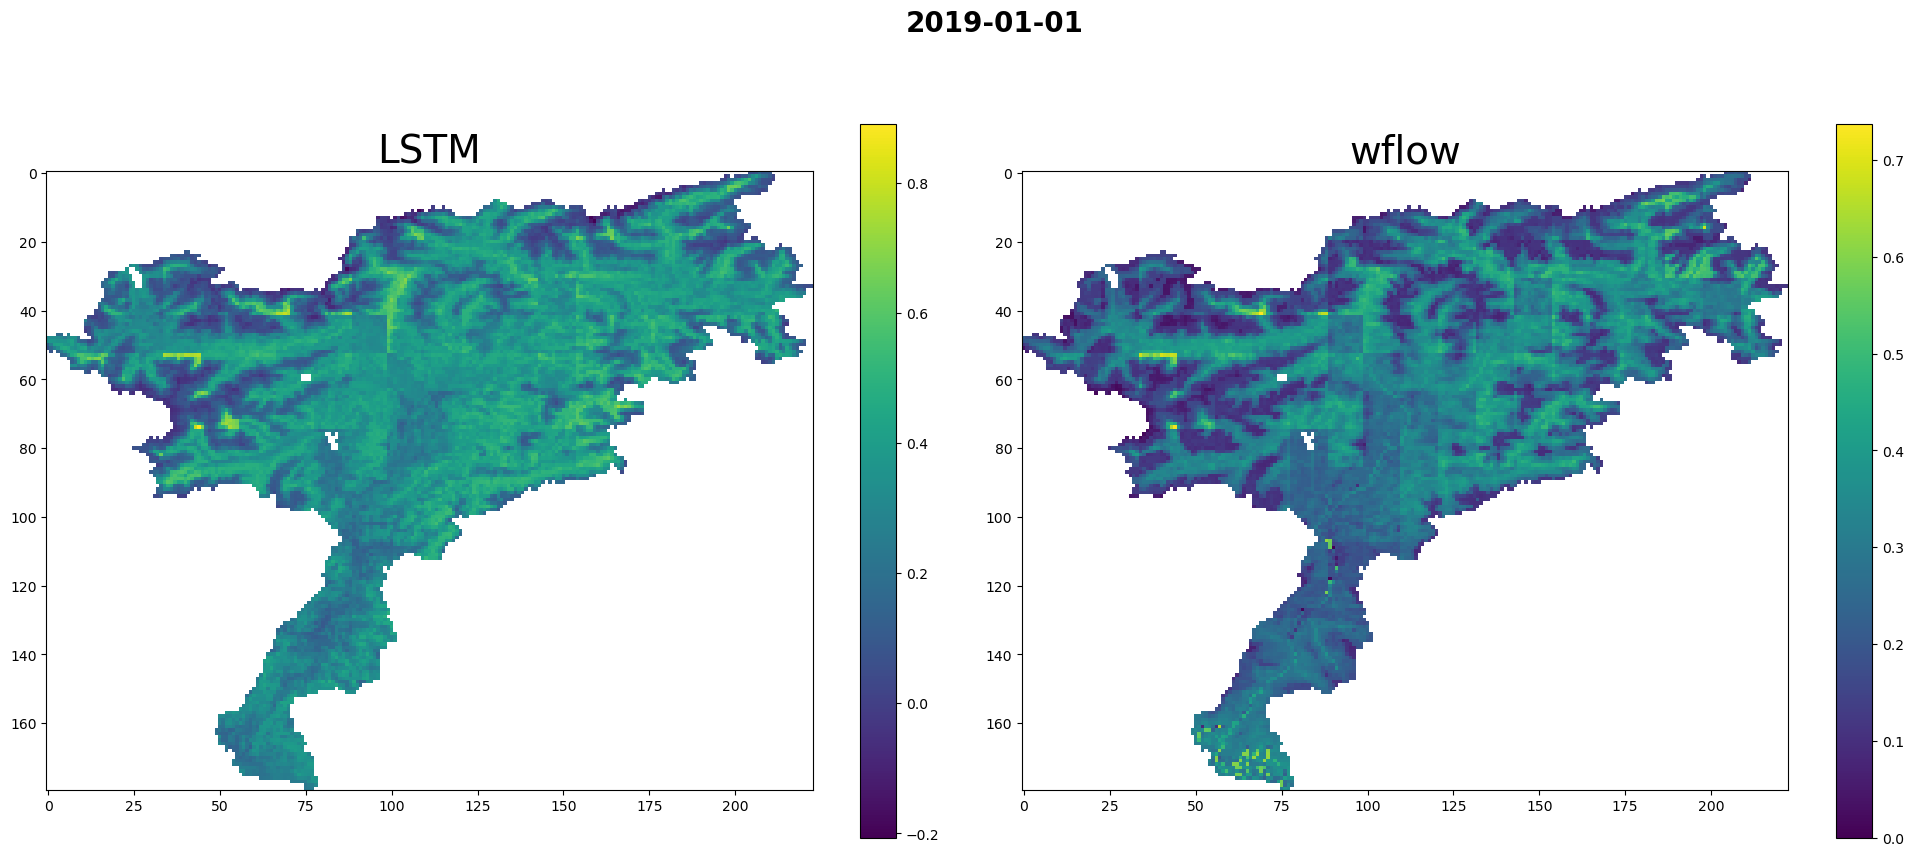

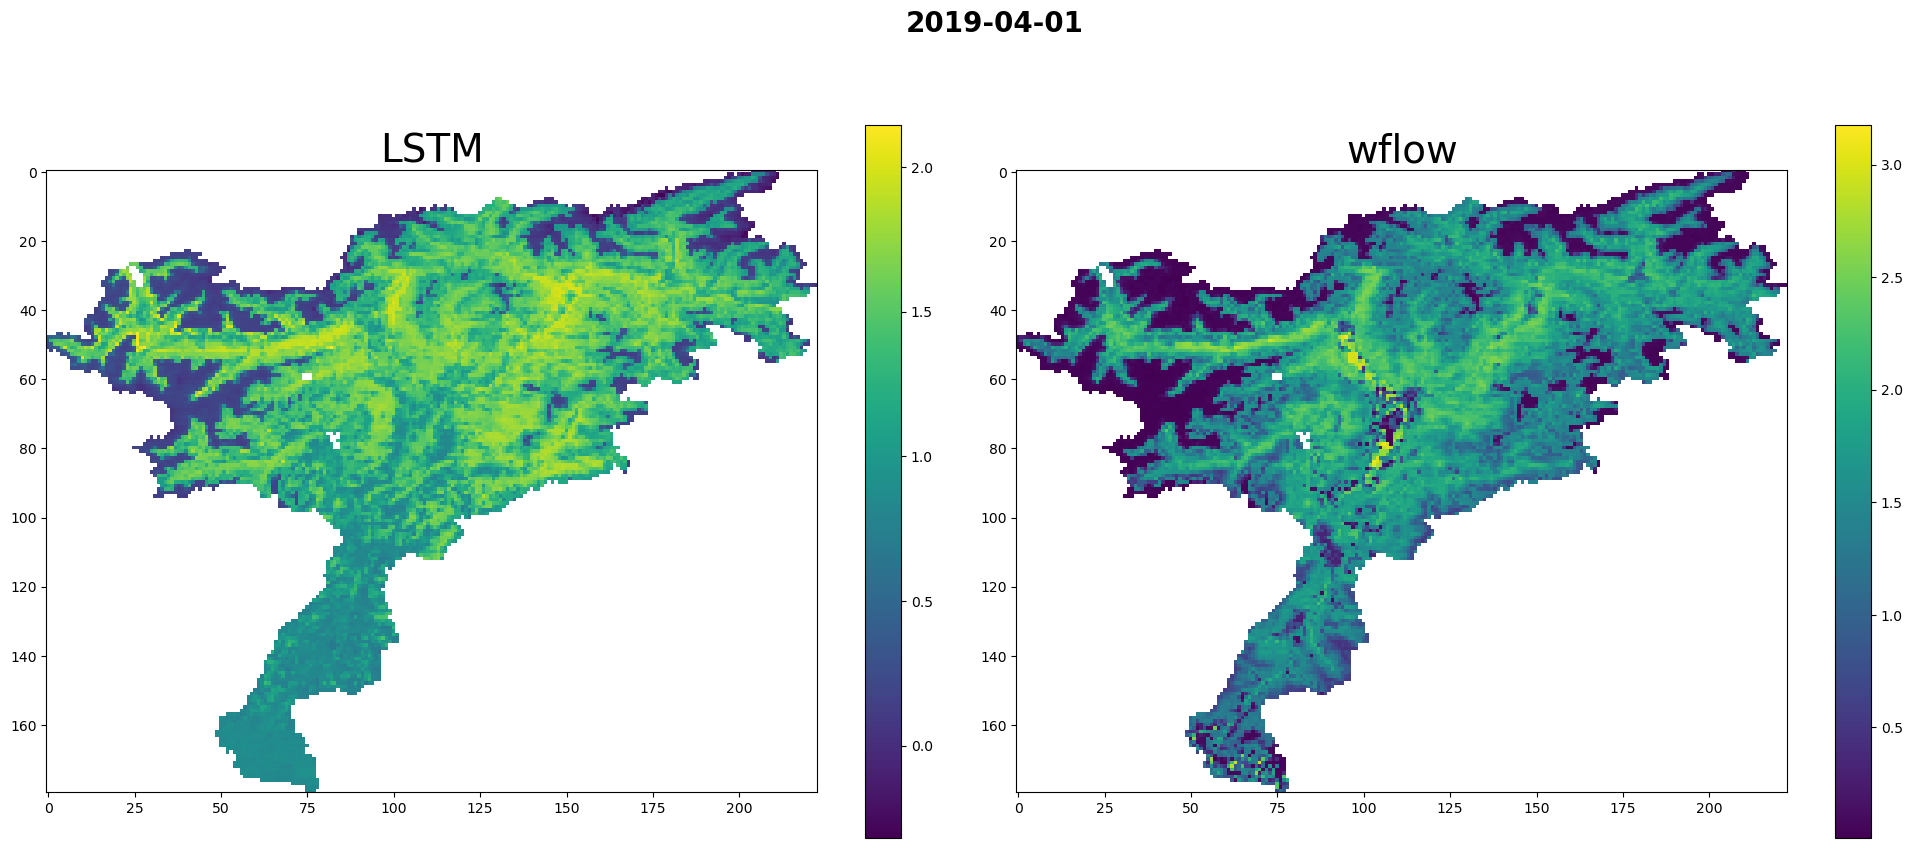

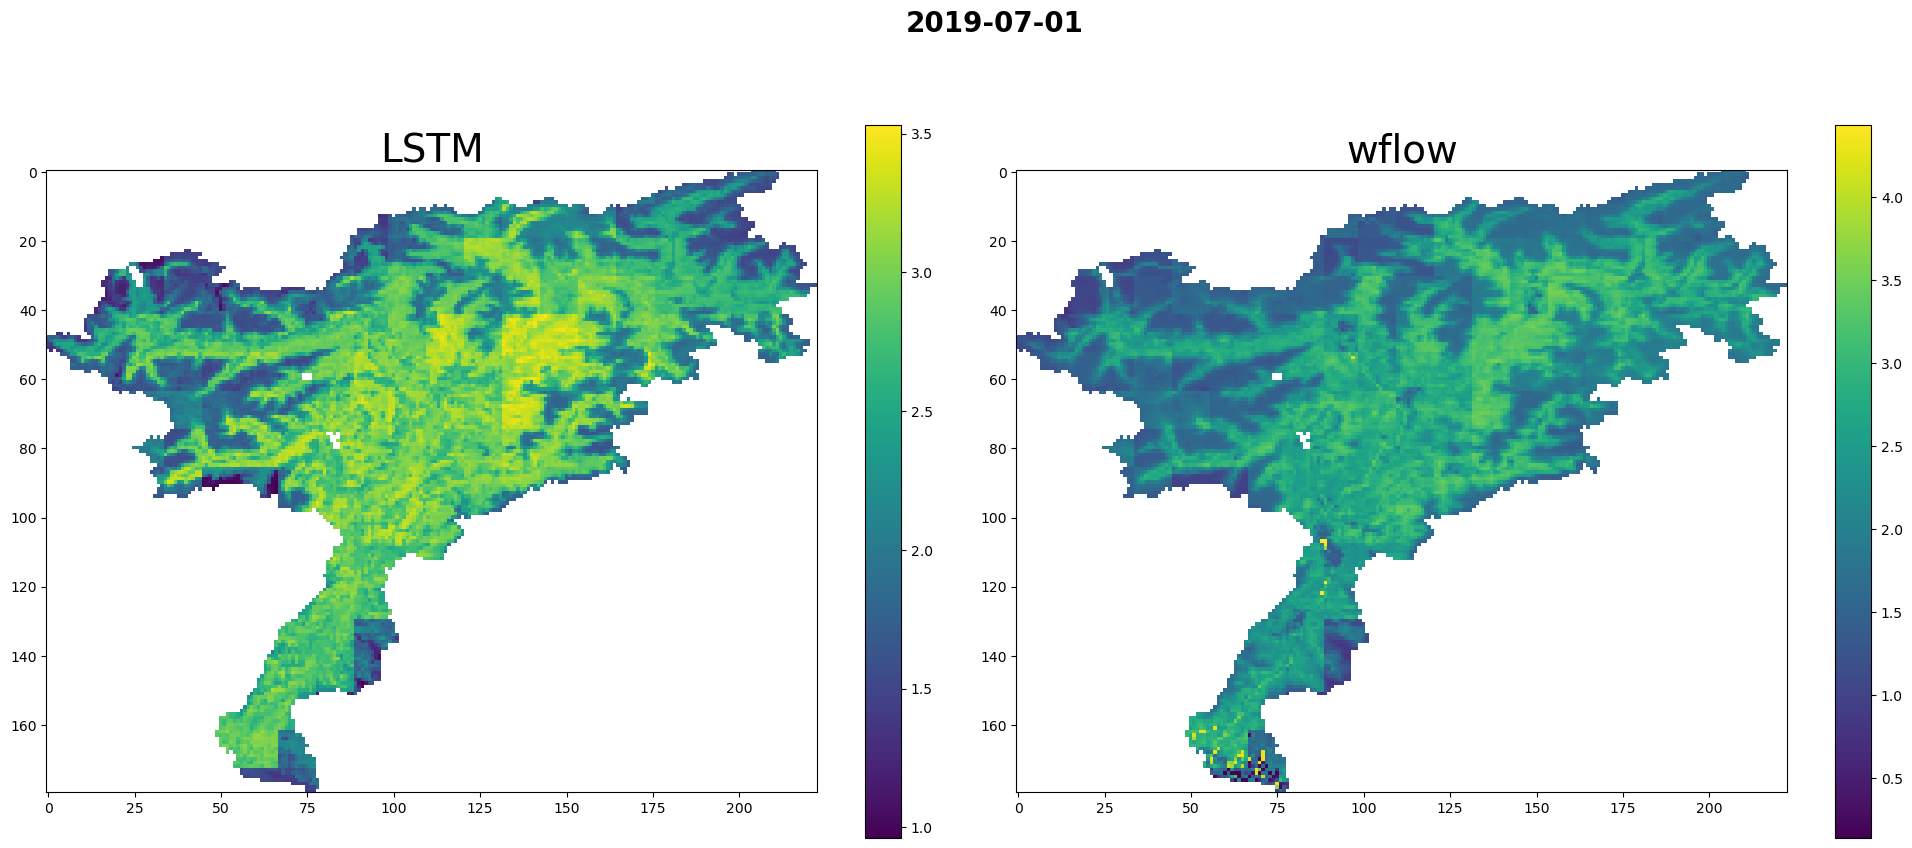

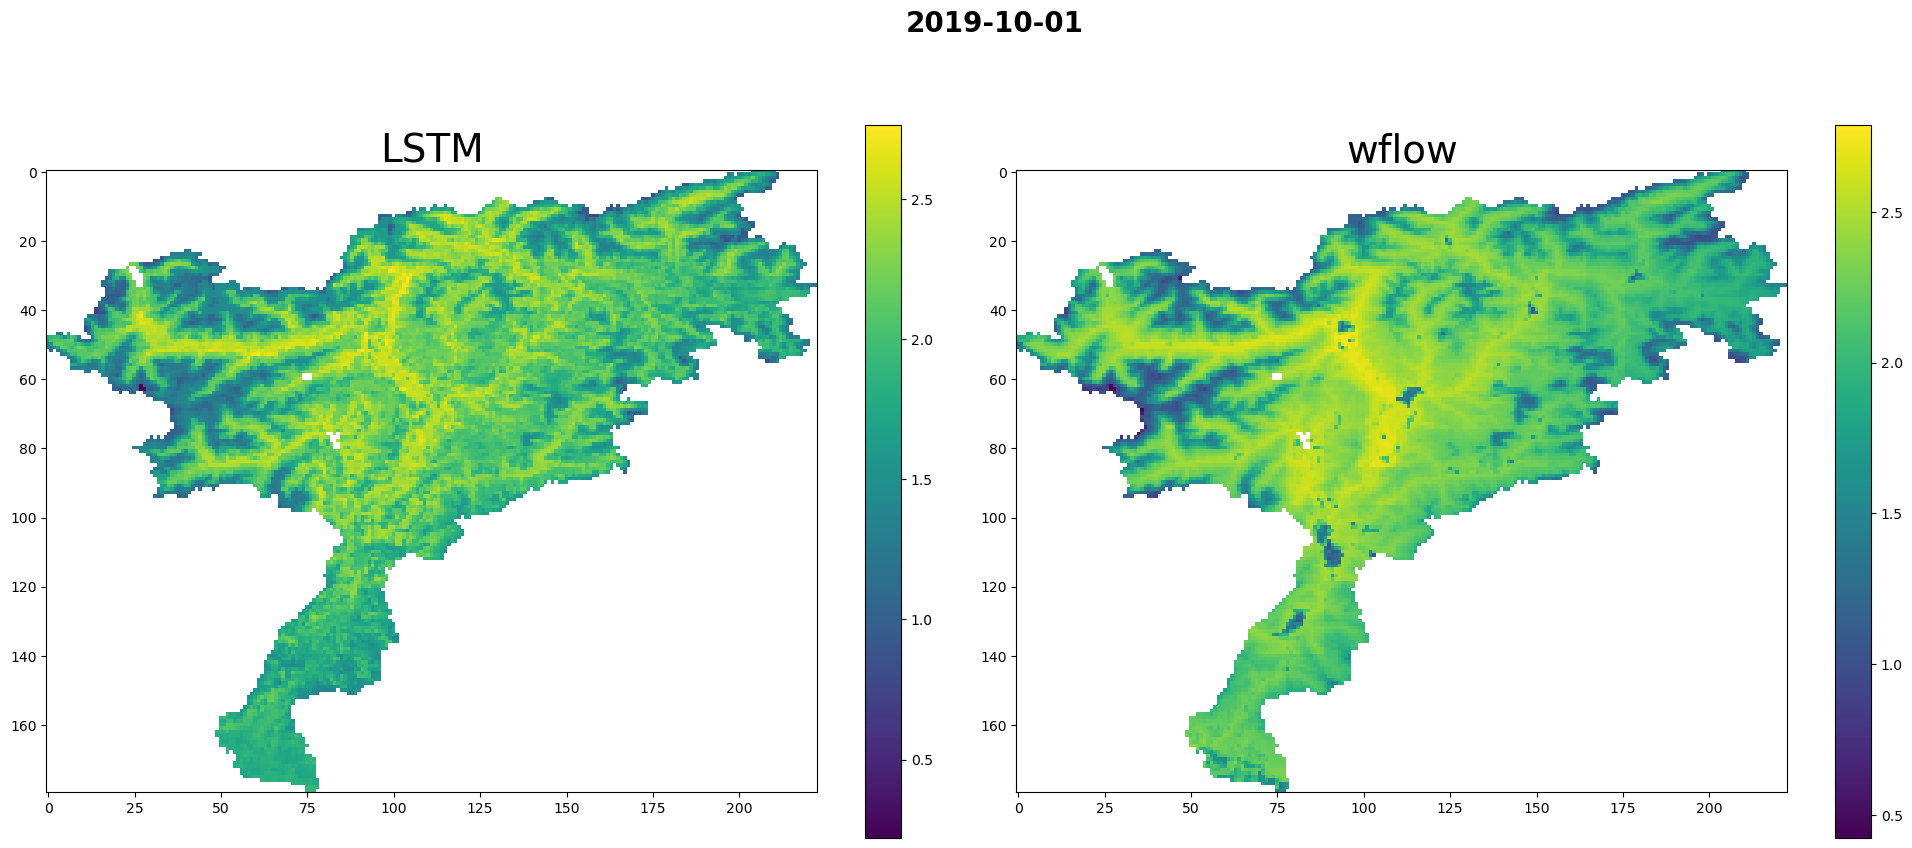

In [254]:
map_at_timesteps(y_target_et, y_pred_et,dates=["2019-01-01","2019-04-01", "2019-07-01", "2019-10-01"])

# SOMS

In [109]:
from minisom import MiniSom
import pandas as pd
import seaborn as sns

In [110]:
from hython.sampler import get_grid_idx

In [111]:
params

<xarray.Dataset>
Dimensions:       (lat: 180, lon: 223)
Coordinates:
  * lat           (lat) float64 47.08 47.07 47.06 47.05 ... 45.46 45.45 45.44
  * lon           (lon) float64 10.29 10.3 10.31 10.32 ... 12.31 12.32 12.33
    layer         int64 1
    spatial_ref   int64 ...
Data variables:
    thetaS        (lat, lon) float32 dask.array<chunksize=(180, 223), meta=np.ndarray>
    thetaR        (lat, lon) float32 dask.array<chunksize=(180, 223), meta=np.ndarray>
    RootingDepth  (lat, lon) float64 dask.array<chunksize=(180, 223), meta=np.ndarray>
    Swood         (lat, lon) float64 dask.array<chunksize=(180, 223), meta=np.ndarray>
    KsatVer       (lat, lon) float32 dask.array<chunksize=(180, 223), meta=np.ndarray>

In [113]:
grid_idx = get_grid_idx(params[static_names[0]])

In [114]:
grid_idx

array([[    0,     1,     2, ...,   220,   221,   222],
       [  223,   224,   225, ...,   443,   444,   445],
       [  446,   447,   448, ...,   666,   667,   668],
       ...,
       [39471, 39472, 39473, ..., 39691, 39692, 39693],
       [39694, 39695, 39696, ..., 39914, 39915, 39916],
       [39917, 39918, 39919, ..., 40137, 40138, 40139]])

In [176]:
df = params.drop_vars("spatial_ref").to_dataframe().reset_index()

In [177]:
grid_idx_long = grid_idx.flatten()

In [178]:
df["grid_idx"] = grid_idx_long

In [179]:
df = df.dropna(axis=0)

In [ ]:
grid_idx_long_nomissing = df["grid_idx"].values

In [187]:
len(grid_idx_long_nomissing)

15426

In [183]:
df = df.drop(["lat","lon", "layer","grid_idx"],axis=1)

In [184]:
# data normalization
df = (df - np.mean(df, axis=0)) / np.std(df, axis=0)
data = df.values

In [185]:
data.shape

(15426, 5)

In [149]:
5*np.sqrt(data.shape[0])

621.0072463345335

In [150]:
14*14

196

In [188]:
som_shape = (1, 5)

In [189]:
som = MiniSom(som_shape[0], som_shape[1], data.shape[1], sigma=.5, learning_rate=.5,
              neighborhood_function='gaussian', random_seed=10,)

In [190]:
som.train(data, num_iteration=50, verbose=True, use_epochs=True,)

 [  62610 / 771300 ]   8% - 0:00:30 left 

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [ 165850 / 771300 ]  22% - 0:00:27 left 

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [ 248756 / 771300 ]  32% - 0:00:23 left 

...

 [ 651009 / 771300 ]  84% - 0:00:05 left 

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [ 737607 / 771300 ]  96% - 0:00:01 left 

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [ 771300 / 771300 ] 100% - 0:00:00 left 
 quantization error: 3.0776983713410138


In [191]:
# each neuron represents a cluster
winner_coordinates = np.array([som.winner(x) for x in data]).T
# with np.ravel_multi_index we convert the bidimensional
# coordinates to a monodimensional index
cluster_index = np.ravel_multi_index(winner_coordinates, som_shape)

In [192]:
cluster_index

array([4, 4, 4, ..., 2, 2, 2])

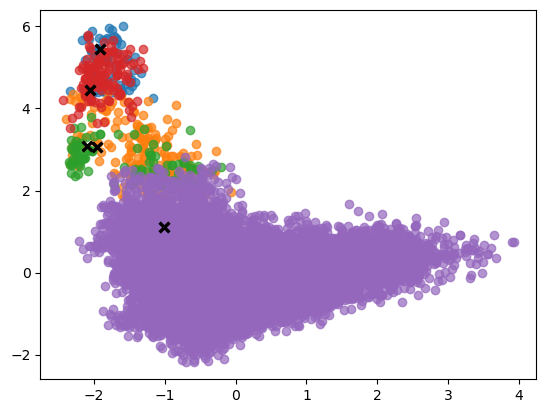

In [193]:
import matplotlib.pyplot as plt
%matplotlib inline

# plotting the clusters using the first 2 dimentions of the data
for c in np.unique(cluster_index):
    plt.scatter(data[cluster_index == c, 0],
                data[cluster_index == c, 1], label='cluster='+str(c), alpha=.7)

# plotting centroids
for centroid in som.get_weights():
    plt.scatter(centroid[:, 0], centroid[:, 1], marker='x', 
                s=3, linewidths=10, color='k', label='centroid')

In [194]:
df["cluster"] = cluster_index

In [195]:
df

,thetaS,thetaR,RootingDepth,Swood,KsatVer,cluster
204,2.531067,0.546739,-1.453429,-1.108119,0.037755,4
205,2.698893,0.659200,-1.515953,-1.108119,0.079304,4
206,2.677747,0.445319,-1.744207,-1.107837,0.230267,4
207,2.260599,0.331310,-1.751268,-1.089326,-0.106442,4
208,2.422433,0.637570,-1.579646,-1.091884,-0.349765,4
...,...,...,...,...,...,...
39771,-2.071361,2.985691,-1.278487,-0.688594,-2.869539,2
39772,-1.903620,2.948130,0.184139,0.736404,-2.760191,1
39992,-1.916753,3.385987,-2.190159,-1.331814,-2.767839,2
39993,-2.035211,2.954250,-1.883817,-1.328019,-2.849763,2


In [196]:
dfmelt = df.melt(id_vars="cluster",value_vars=static_names)

In [197]:
dfmelt


,cluster,variable,value
0,4,thetaS,2.531067
1,4,thetaS,2.698893
2,4,thetaS,2.677747
3,4,thetaS,2.260599
4,4,thetaS,2.422433
...,...,...,...
77125,2,KsatVer,-2.869539
77126,1,KsatVer,-2.760191
77127,2,KsatVer,-2.767839
77128,2,KsatVer,-2.849763


<AxesSubplot: xlabel='variable', ylabel='value'>

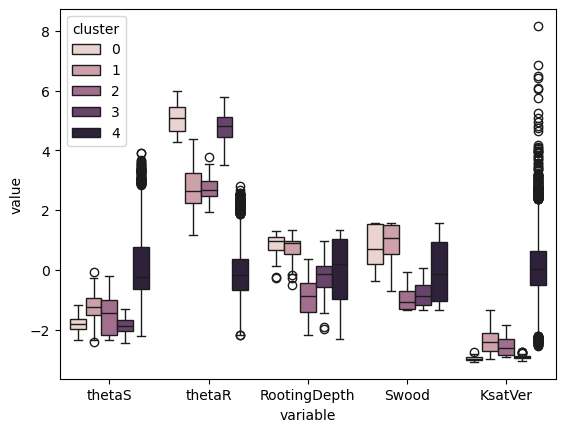

In [198]:
sns.boxplot(dfmelt, x= "variable", y="value", hue="cluster")

In [199]:
# want to sample 
# 1) by defining density 
# 2) by sampling evenly
r = df.groupby("cluster").count() / len(cluster_index)

In [200]:
r

,thetaS,thetaR,RootingDepth,Swood,KsatVer
cluster,,,,,
0,0.004603,0.004603,0.004603,0.004603,0.004603
1,0.015040,0.015040,0.015040,0.015040,0.015040
2,0.005964,0.005964,0.005964,0.005964,0.005964
3,0.008038,0.008038,0.008038,0.008038,0.008038
4,0.966356,0.966356,0.966356,0.966356,0.966356


In [201]:
len(cluster_index)

15426

In [211]:
freq = 0.1 # 1 in five, or 20 % 

In [212]:
n_subsamples = int(freq*1452)
n_subsamples

145

In [213]:
# plt.imshow(df.cluster.values.reshape(sampler_train_meta.sampled_grid[:2]))
# plt.colorbar()

In [214]:
df["grid_idx"] = grid_idx_long_nomissing

In [215]:
df_train =  df.groupby('cluster', group_keys=False).apply(lambda x: x.sample(frac=freq))#, include_groups=False)

In [216]:
df_val =  df.groupby('cluster', group_keys=False).apply(lambda x: x.sample(frac=freq)) #, include_groups=False)

In [217]:
sampler_train_meta.idx_sampled_1d = df_train.grid_idx.values
sampler_val_meta.idx_sampled_1d = df_val.grid_idx.values

(<Figure size 1000x1000 with 1 Axes>,
 <AxesSubplot: title={'center': 'layer = 1, spatial_ref = 0'}, xlabel='longitude coordinate\n[degrees_east]', ylabel='latitude coordinate\n[degrees_north]'>)

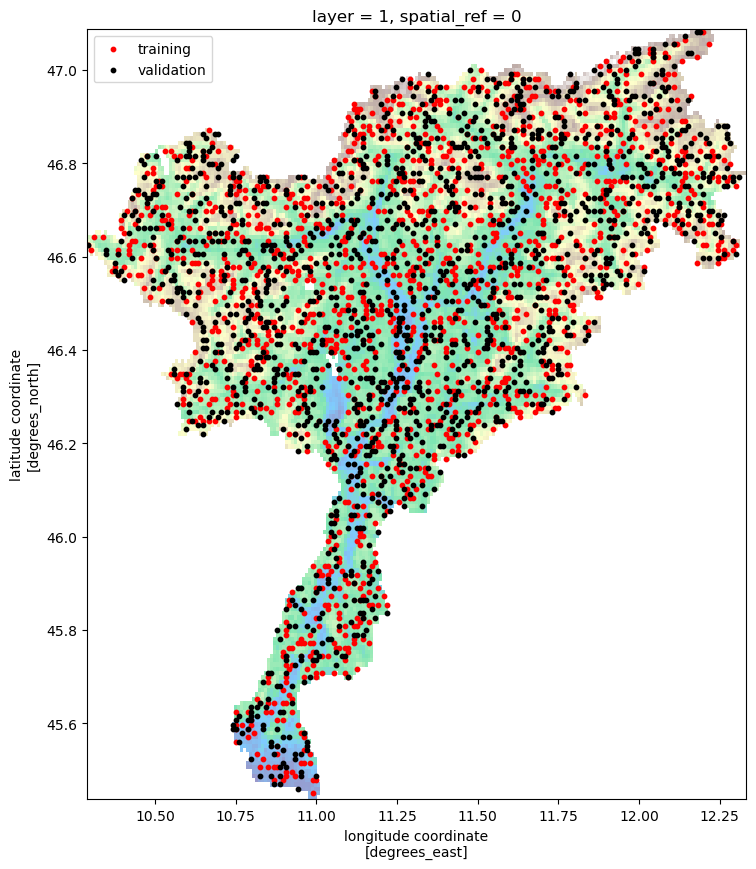

In [218]:
plot_sampler(params.thetaS,sampler_train_meta, sampler_val_meta)